In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("../data/raw/CTG.xls", sheet_name="Data", header=1)
print(df.shape)
print(df.columns.tolist())
df.head()

(2129, 46)
['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'Unnamed: 9', 'LB', 'AC.1', 'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'Unnamed: 31', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'Unnamed: 42', 'CLASS', 'Unnamed: 44', 'NSP']


,b,e,AC,FM,UC,DL,DS,DP,DR,Unnamed: 9,...,E,AD,DE,LD,FS,SUSP,Unnamed: 42,CLASS,Unnamed: 44,NSP
0,240.0,357.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,NaN,9.0,NaN,2.0
1,5.0,632.0,4.0,0.0,4.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
2,177.0,779.0,2.0,0.0,5.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
3,411.0,1192.0,2.0,0.0,6.0,2.0,0.0,0.0,0.0,NaN,...,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,NaN,6.0,NaN,1.0
4,533.0,1147.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,2.0,NaN,1.0


In [2]:
# Keep the 21 official features + target
rename_map = {"AC.1": "AC", "FM.1": "FM", "UC.1": "UC",
              "DL.1": "DL", "DS.1": "DS", "DP.1": "DP"}

feature_cols = ["LB", "AC.1", "FM.1", "UC.1", "DL.1", "DS.1", "DP.1",
                "ASTV", "MSTV", "ALTV", "MLTV", "Width", "Min", "Max",
                "Nmax", "Nzeros", "Mode", "Mean", "Median", "Variance", "Tendency"]

log = {}
log["Original rows"] = len(df)
log["Original columns"] = df.shape[1]

# 1. Keep only features + target (drops b, e, DR, raw counts, CLASS, A-SUSP, Unnamed)
data = df[feature_cols + ["NSP"]].rename(columns=rename_map).copy()
log["Columns kept"] = data.shape[1]

# 2. Missing values
log["Rows with missing values"] = int(data.isna().any(axis=1).sum())
data = data.dropna()

# 3. Duplicates
log["Duplicate rows"] = int(data.duplicated().sum())
data = data.drop_duplicates()

# 4. Target verification
data["NSP"] = data["NSP"].astype(int)
log["NSP unique values"] = sorted(data["NSP"].unique().tolist())

# 5. Invalid values (negative numbers are impossible here)
log["Negative values"] = int((data.drop(columns="NSP") < 0).sum().sum())

log["Final rows"] = len(data)

for k, v in log.items():
    print(f"{k}: {v}")

print("\nData types:")
print(data.dtypes)

Original rows: 2129
Original columns: 46
Columns kept: 22
Rows with missing values: 3
Duplicate rows: 12
NSP unique values: [1, 2, 3]
Negative values: 165
Final rows: 2114

Data types:
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Min         float64
Max         float64
Nmax        float64
Nzeros      float64
Mode        float64
Mean        float64
Median      float64
Variance    float64
Tendency    float64
NSP           int64
dtype: object


In [3]:
# 1. Which columns have negatives?
neg = (data.drop(columns="NSP") < 0).sum()
print("Negatives per column:")
print(neg[neg > 0])
print("\nTendency values:", sorted(data["Tendency"].unique()))

# 2. Save cleaned dataset
data.to_csv("../data/processed/ctg_clean.csv", index=False)
print("\nSaved cleaned data:", data.shape)

# 3. Class distribution
counts = data["NSP"].value_counts().sort_index()
pct = (counts / len(data) * 100).round(2)
labels = {1: "Normal", 2: "Suspect", 3: "Pathological"}
dist = pd.DataFrame({"Class": [labels[i] for i in counts.index],
                     "Count": counts.values,
                     "Percent": pct.values})
print("\nClass distribution:")
print(dist)

Negatives per column:
Tendency    165
dtype: int64

Tendency values: [np.float64(-1.0), np.float64(0.0), np.float64(1.0)]

Saved cleaned data: (2114, 22)

Class distribution:
          Class  Count  Percent
0        Normal   1647    77.91
1       Suspect    292    13.81
2  Pathological    175     8.28


Cell A : CLASS DISTRIBUTION

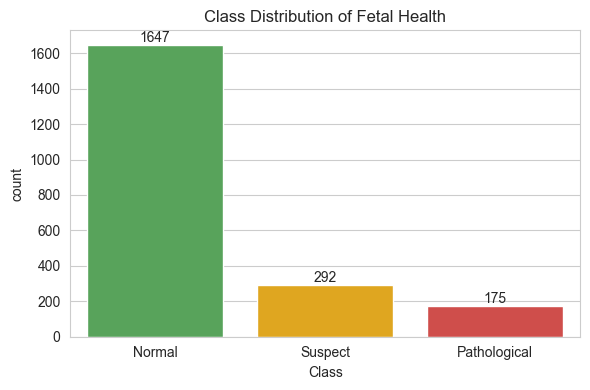

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
label_names = {1: "Normal", 2: "Suspect", 3: "Pathological"}
data["Class"] = data["NSP"].map(label_names)
order = ["Normal", "Suspect", "Pathological"]

plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Class", hue="Class", data=data, order=order,
                   palette={"Normal": "#4caf50", "Suspect": "#ffb300", "Pathological": "#e53935"},
                   legend=False)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Class Distribution of Fetal Health")
plt.tight_layout()
plt.savefig("../results/figures/01_class_distribution.png", dpi=150)
plt.show()

Cell B : CORRELATION HEATMAP

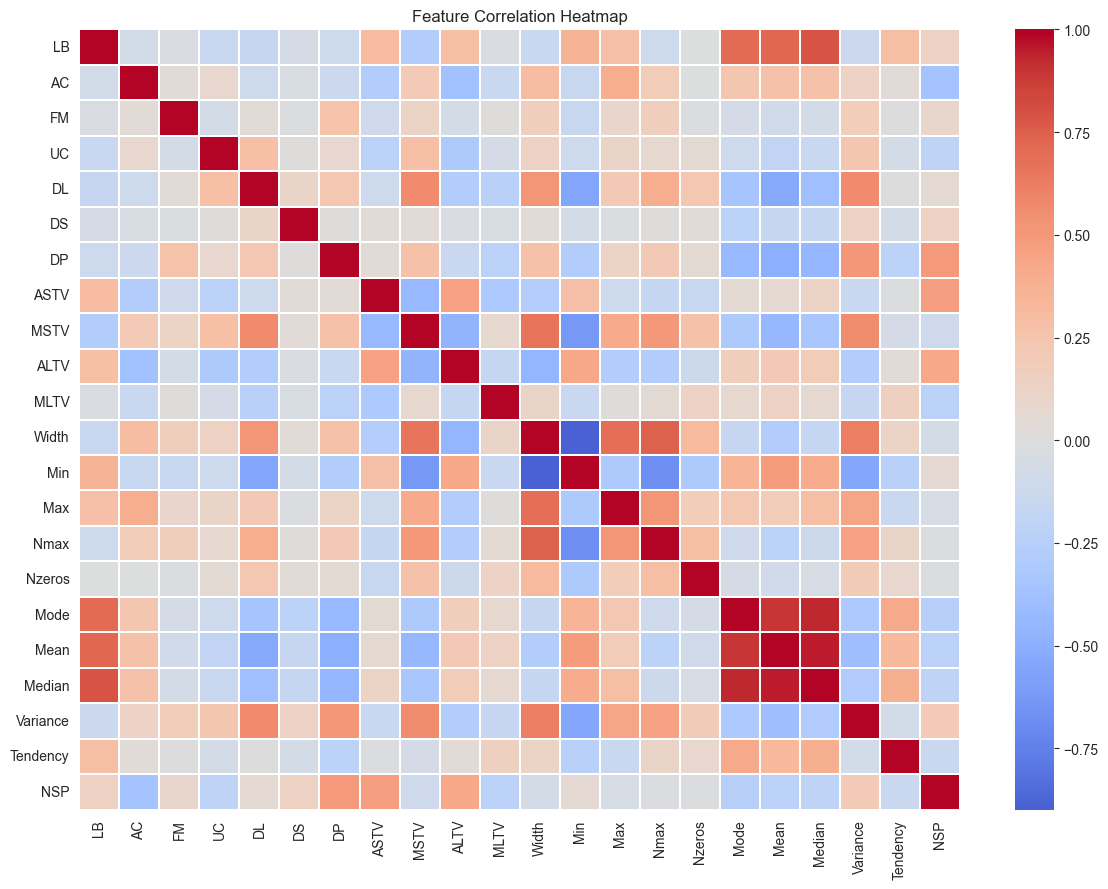

DP        0.490210
ASTV      0.469712
ALTV      0.421632
AC        0.363690
Mode      0.253658
Mean      0.230329
MLTV      0.225753
Median    0.208396
Name: NSP, dtype: float64

Pairs with correlation > 0.9: [('Mode', 'Median', np.float64(0.93)), ('Mean', 'Median', np.float64(0.95))]


In [5]:
features = [c for c in data.columns if c not in ["NSP", "Class"]]

plt.figure(figsize=(12, 9))
sns.heatmap(data[features + ["NSP"]].corr(), cmap="coolwarm", center=0,
            annot=False, linewidths=0.3)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../results/figures/02_correlation_heatmap.png", dpi=150)
plt.show()

# Strongest correlations with the target
print(data[features + ["NSP"]].corr()["NSP"].drop("NSP").abs().sort_values(ascending=False).head(8))

# Highly correlated feature pairs (>0.9)
corr = data[features].corr().abs()
pairs = [(a, b, round(corr.loc[a, b], 2)) for i, a in enumerate(features)
         for b in features[i+1:] if corr.loc[a, b] > 0.9]
print("\nPairs with correlation > 0.9:", pairs)

Cell C: FEATURE DISTRIBUTIONS

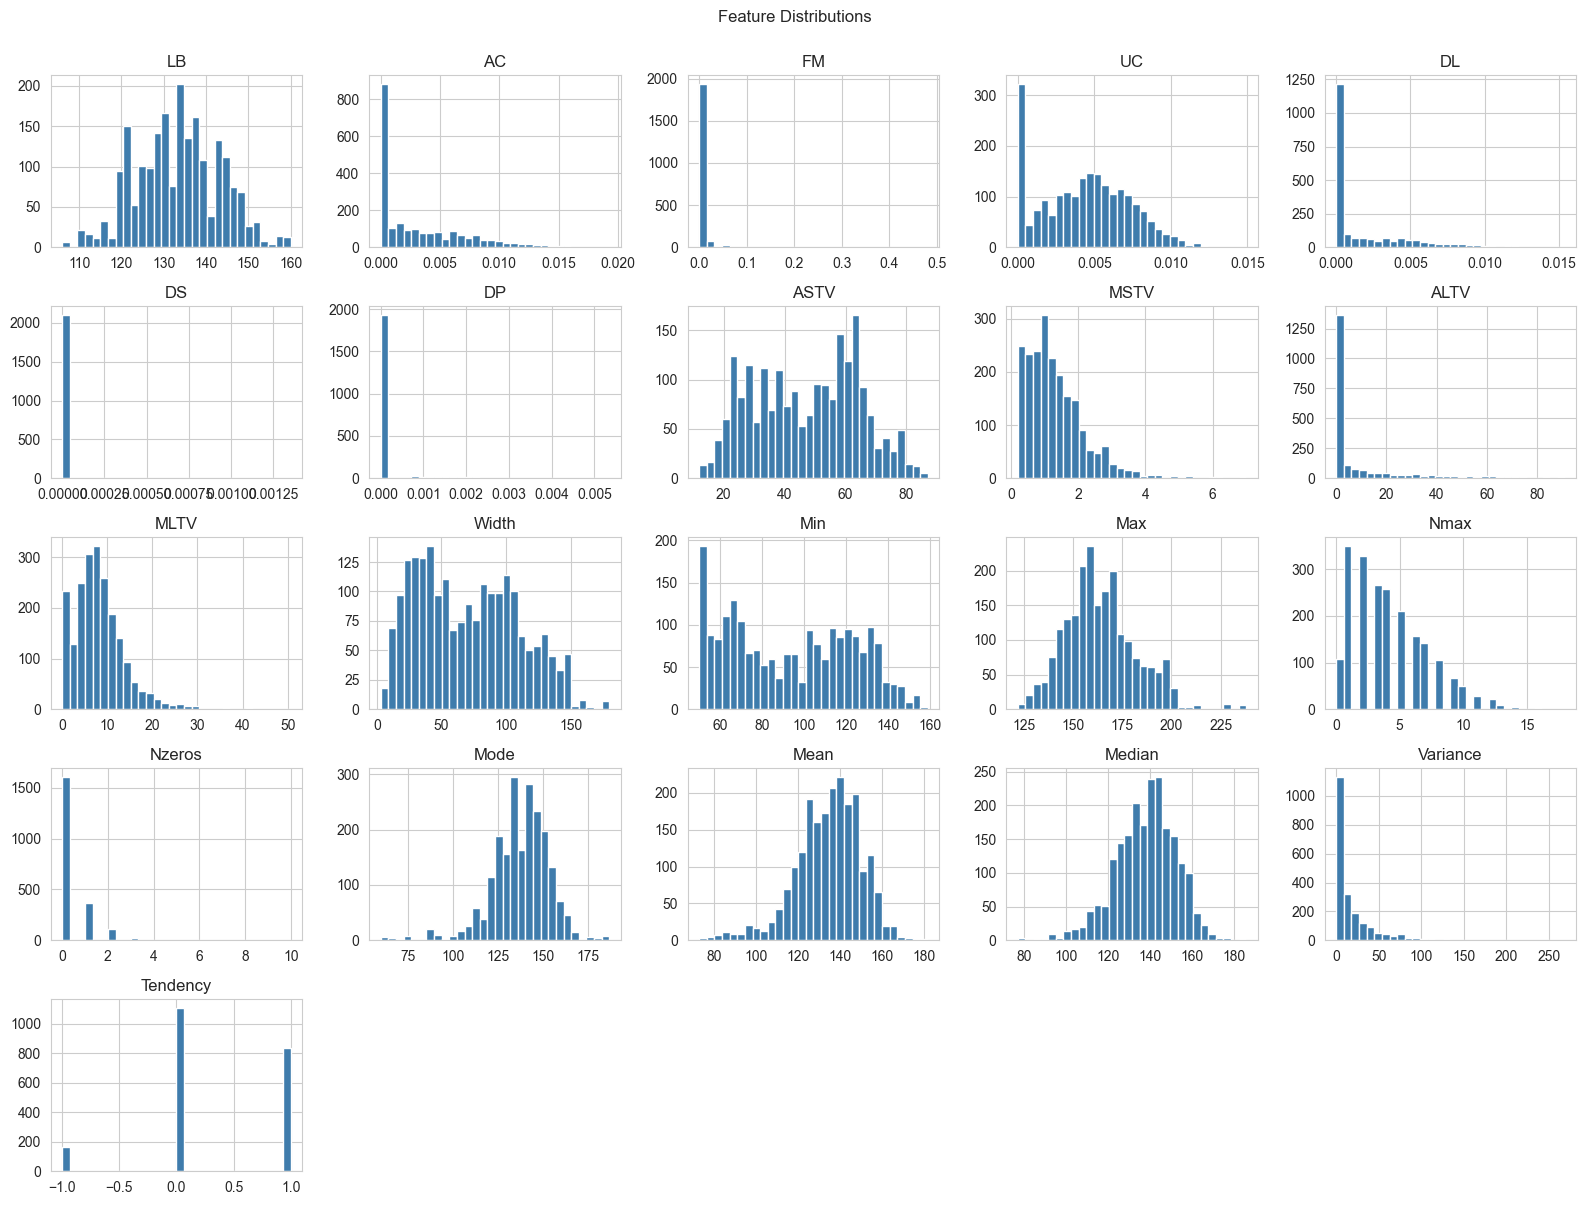

In [6]:
data[features].hist(bins=30, figsize=(16, 12), color="#3f7cac")
plt.suptitle("Feature Distributions", y=1.0)
plt.tight_layout()
plt.savefig("../results/figures/03_feature_distributions.png", dpi=150)
plt.show()

Step 6: boxplots by class

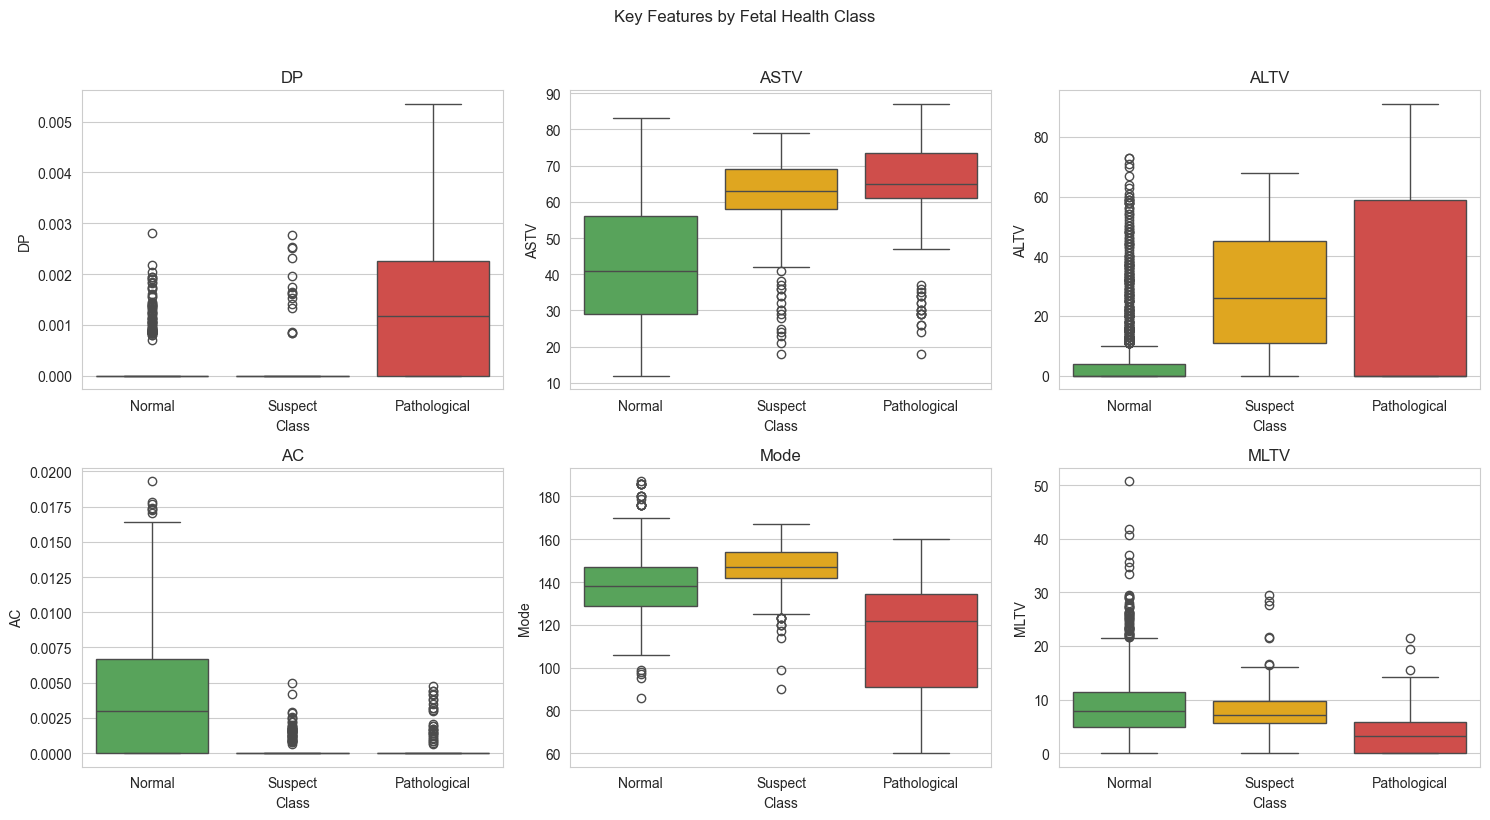

In [9]:
top_feats = ["DP", "ASTV", "ALTV", "AC", "Mode", "MLTV"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, f in zip(axes.ravel(), top_feats):
    sns.boxplot(x="Class", y=f, hue="Class", data=data, order=order,
                palette={"Normal": "#4caf50", "Suspect": "#ffb300", "Pathological": "#e53935"},
                legend=False, ax=ax)
    ax.set_title(f)
plt.suptitle("Key Features by Fetal Health Class", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/04_boxplots_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

Step 7: PCA plot

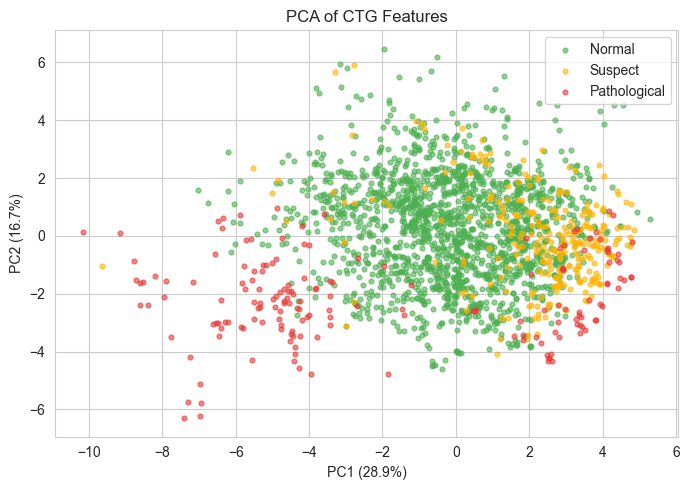

Variance explained by 2 components: 45.6 %


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_all = data[features]
X_scaled = StandardScaler().fit_transform(X_all)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
colors = {"Normal": "#4caf50", "Suspect": "#ffb300", "Pathological": "#e53935"}
for c in order:
    mask = data["Class"] == c
    plt.scatter(pcs[mask, 0], pcs[mask, 1], s=12, alpha=0.6, label=c, color=colors[c])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of CTG Features")
plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/05_pca.png", dpi=150)
plt.show()

print("Variance explained by 2 components:", round(pca.explained_variance_ratio_.sum()*100, 1), "%")

Step 8: Train/test split and scaler

In [11]:
from sklearn.model_selection import train_test_split
import joblib

X = data[features]
y = data["NSP"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

train = X_train.copy(); train["NSP"] = y_train
test = X_test.copy();   test["NSP"] = y_test

train.to_csv("../data/processed/train.csv", index=False)
test.to_csv("../data/processed/test.csv", index=False)

# Scaler fitted on TRAIN only (for Logistic Regression later)
scaler = StandardScaler().fit(X_train)
joblib.dump(scaler, "../data/processed/scaler.pkl")

print("Train:", train.shape, " Test:", test.shape)
print("\nTrain class %:\n", (y_train.value_counts(normalize=True).sort_index()*100).round(2))
print("\nTest class %:\n", (y_test.value_counts(normalize=True).sort_index()*100).round(2))

Train: (1691, 22)  Test: (423, 22)

Train class %:
 NSP
1    77.88
2    13.84
3     8.28
Name: proportion, dtype: float64

Test class %:
 NSP
1    78.01
2    13.71
3     8.27
Name: proportion, dtype: float64


Step 9: Feature selection (training data only)

     Feature   F_score  p_value  Selected
0         DP  485.3461   0.0000      True
1       ALTV  288.7607   0.0000      True
2       ASTV  282.7722   0.0000      True
3       Mean  238.1540   0.0000      True
4       Mode  214.6998   0.0000      True
5     Median  196.5918   0.0000      True
6         AC  157.7124   0.0000      True
7   Variance  147.5480   0.0000      True
8         LB  103.9716   0.0000      True
9       MSTV  100.0655   0.0000      True
10        UC   83.4058   0.0000     False
11       Min   71.8075   0.0000     False
12      MLTV   55.7388   0.0000     False
13        DL   47.3405   0.0000     False
14     Width   47.3369   0.0000     False
15  Tendency   35.6521   0.0000     False
16        DS   30.1372   0.0000     False
17        FM   12.9470   0.0000     False
18      Nmax    9.1702   0.0001     False
19       Max    2.4542   0.0862     False
20    Nzeros    0.7910   0.4536     False

Top 10 features: ['DP', 'ALTV', 'ASTV', 'Mean', 'Mode', 'Median', 'AC', 'Va

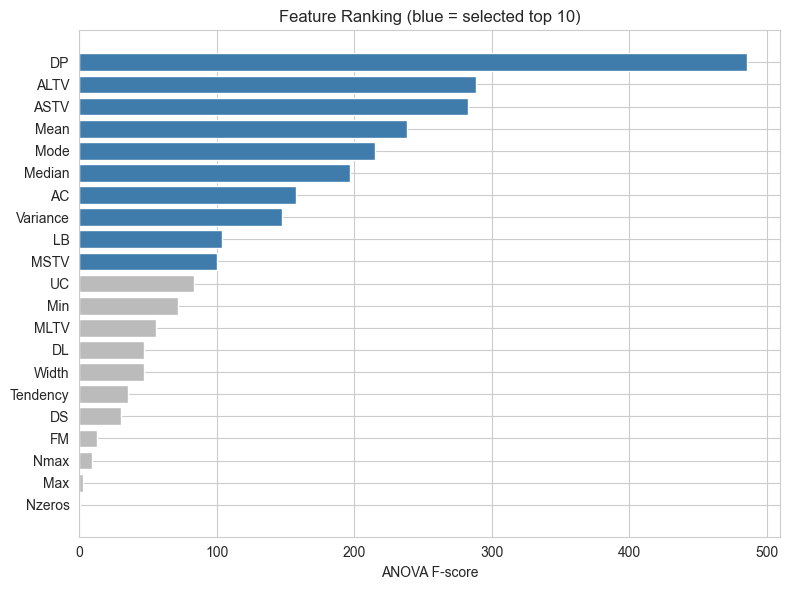


               Model        Features  CV Macro F1    Std
      Random Forest All 21 features       0.8874 0.0281
      Random Forest Top 10 features       0.8811 0.0168
Logistic Regression All 21 features       0.7871 0.0218
Logistic Regression Top 10 features       0.7823 0.0320


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
import json

# 1. ANOVA F-test on TRAIN only
selector = SelectKBest(score_func=f_classif, k=10).fit(X_train, y_train)

scores = pd.DataFrame({
    "Feature": features,
    "F_score": selector.scores_,
    "p_value": selector.pvalues_,
    "Selected": selector.get_support()
}).sort_values("F_score", ascending=False).reset_index(drop=True)

print(scores.round(4).to_string())

top10 = scores.loc[scores["Selected"], "Feature"].tolist()
print("\nTop 10 features:", top10)

scores.to_csv("../results/feature_selection_scores.csv", index=False)
with open("../data/processed/top10_features.json", "w") as f:
    json.dump(top10, f)

# 2. Bar chart of F-scores
plt.figure(figsize=(8, 6))
colors_bar = ["#3f7cac" if s else "#bbbbbb" for s in scores["Selected"]]
plt.barh(scores["Feature"][::-1], scores["F_score"][::-1], color=colors_bar[::-1])
plt.xlabel("ANOVA F-score")
plt.title("Feature Ranking (blue = selected top 10)")
plt.tight_layout()
plt.savefig("../results/figures/06_feature_selection.png", dpi=150)
plt.show()

# 3. Compare all 21 vs top 10 using 5-fold CV on TRAIN only (macro F1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

rows = []
for name, model in [("Random Forest", rf), ("Logistic Regression", lr)]:
    for label, cols in [("All 21 features", features), ("Top 10 features", top10)]:
        s = cross_val_score(model, X_train[cols], y_train, cv=cv, scoring="f1_macro")
        rows.append({"Model": name, "Features": label,
                     "CV Macro F1": round(s.mean(), 4), "Std": round(s.std(), 4)})
comparison = pd.DataFrame(rows)
print("\n", comparison.to_string(index=False))
comparison.to_csv("../results/feature_selection_comparison.csv", index=False)